# Prithvi-UNet Phase-2 Refinement Training: SA T2 ACCESS-CM2 (static)

This notebook trains the **Phase-2 stochastic residual refiner** on top of a frozen Phase-1 deterministic UNet checkpoint.

Four refinement architectures are available — select one by pointing `CONFIG_PATH` at the corresponding YAML:

| YAML file | Refinement type | Notes |
|---|---|---|
| `SA_T2_ACCESS-CM2_static_diffusion_unet.yaml` | `diffusion_unet` | DDIM, cosine schedule, η=0 |
| `SA_T2_ACCESS-CM2_static_flow_matching_unet.yaml` | `flow_matching_unet` | Euler ODE solver |
| `SA_T2_ACCESS-CM2_static_diffusion_transformer.yaml` | `diffusion_transformer` | ViT backbone |
| `SA_T2_ACCESS-CM2_static_flow_matching_transformer.yaml` | `flow_matching_transformer` | Heun ODE solver |

All four train on the residual `target − UNet_output` with Phase 1 frozen.

---
## Setup

Python ≥ 3.10 required. Make sure the current working directory is `granite-wxc/`.

In [1]:
import os
import sys
from pathlib import Path

# Resolve repo root relative to this notebook's location
REPO_ROOT = Path(__file__).resolve().parents[3] if "__file__" in dir() else Path.cwd().parents[2]
# Fallback: walk up from cwd until we find the repo marker
if not (REPO_ROOT / "examples" / "CORDEX_ML").exists():
    _here = Path.cwd()
    for _p in [_here, *_here.parents]:
        if (_p / "examples" / "CORDEX_ML").exists():
            REPO_ROOT = _p
            break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(str(REPO_ROOT / "examples/CORDEX_ML"))
print(f"Repo root        : {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")

Repo root        : d:\granite-wxc
Working directory: d:\granite-wxc\examples\CORDEX_ML


In [ ]:
# ===================== CONFIGURATION / HARDWARE (EDIT ME) =====================
import subprocess

# --- refinement YAML to use (edit this line to switch architectures) ---
CONFIG_YAML = "SA_T2_ACCESS-CM2_static_diffusion_transformer.yaml"

# --- training options ---
resume_from_checkpoint = False      # set True to resume from checkpoint_dir/last.ckpt
resume_checkpoint_path = None       # optional explicit path override
save_every = 1                      # save a named epoch checkpoint every N epochs
seed = 42

# --- GPU selection ---
max_gpus = 1
force_visible_devices = None        # e.g. "2" to pin to physical GPU 2

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


def _query_gpu_stats():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,memory.total,memory.used,utilization.gpu",
             "--format=csv,noheader,nounits"], text=True,
        )
    except Exception:
        return []
    stats = []
    for line in out.strip().splitlines():
        idx, total, used, util = [p.strip() for p in line.split(",")]
        util_n = int("".join(c for c in util if c.isdigit()) or "100")
        total_mb, used_mb = int(total), int(used)
        stats.append({"index": int(idx), "total_mb": total_mb, "used_mb": used_mb,
                      "free_mb": max(0, total_mb - used_mb), "util": util_n})
    return stats


gpu_stats = _query_gpu_stats()
if force_visible_devices:
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = str(force_visible_devices)
    selected = [int(x.strip()) for x in str(force_visible_devices).split(",") if x.strip()]
elif gpu_stats:
    ranked = sorted(gpu_stats, key=lambda g: (-g["free_mb"], g["util"]))
    selected = [g["index"] for g in ranked[:max_gpus]]
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
else:
    selected = []

USE_GPU = bool(selected)
print(f"Selected physical GPUs: {selected}")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES', '<unset>')}")
for s in selected:
    stat = next((g for g in gpu_stats if g["index"] == s), None)
    if stat:
        print(f"  GPU {s}: {stat['free_mb']/1024:.1f} GB free / {stat['total_mb']/1024:.1f} GB total  util={stat['util']}%")

Selected physical GPUs: [0]
CUDA_VISIBLE_DEVICES=0
  GPU 0: 92.7 GB free / 95.6 GB total  util=13%


In [3]:
import logging
import warnings

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from granitewxc.utils.config import get_config
from granitewxc.models.model import get_finetune_model_UNET
from granitewxc.refinement.two_phase import build_two_phase_model
from granitewxc.refinement.training import RefinementTrainer
from granitewxc.refinement.checkpoint import load_phase1_state_dict
from granitewxc.utils.predictands import build_predictand_specs

logging.disable(logging.CRITICAL)
warnings.simplefilter("ignore", FutureWarning)

os.chdir(str(REPO_ROOT / "examples/CORDEX_ML"))

# Import the same dataloader utilities used by the Phase-1 notebook
sys.path.insert(0, str(REPO_ROOT / "examples/CORDEX_ML"))
from cordex_training import get_dataloaders as build_cordex_dataloaders

print("Imports OK.")

Imports OK.


---
## Load configuration

In [4]:
PROJECT_DIR = REPO_ROOT / "examples/CORDEX_ML"
CONFIG_PATH = PROJECT_DIR / CONFIG_YAML

config = get_config(str(CONFIG_PATH))

# Notebook-safe overrides: single worker, no pin_memory to avoid CUDA allocator pressure
config.batch_size = 1
config.dl_num_workers = 2
config.dl_prefetch_size = 0
config.dl_pin_memory = False
config.device_target = "cuda" if USE_GPU else "cpu"

# Keep geometry fixed
config.data.train_crop_size_lat = int(config.data.target_size_lat)
config.data.train_crop_size_lon = int(config.data.target_size_lon)
config.data.val_crop_size_lat = int(config.data.target_size_lat)
config.data.val_crop_size_lon = int(config.data.target_size_lon)

# model.refinement and model.phase1 are stored as plain dicts by ModelConfig
refinement_type = config.model.refinement["type"]
checkpoint_dir = str(getattr(config, "checkpoint_dir",
    PROJECT_DIR / "experiments/refinement_checkpoints/SA_T2_ACCESS-CM2_static" / refinement_type))
phase1_ckpt_path = str(REPO_ROOT / config.model.phase1["checkpoint"])

print(f"Config          : {CONFIG_PATH}")
print(f"Refinement type : {refinement_type}")
print(f"Phase-1 ckpt    : {phase1_ckpt_path}")
print(f"Checkpoint dir  : {checkpoint_dir}")
print(f"Epochs          : {config.num_epochs}")
print(f"Learning rate   : {config.learning_rate}")

Config          : d:\granite-wxc\examples\CORDEX_ML\SA_T2_ACCESS-CM2_static_flow_matching_unet.yaml
Refinement type : flow_matching_unet
Phase-1 ckpt    : d:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase1_unet\best.ckpt
Checkpoint dir  : ./examples/CORDEX_ML/experiments/refinement_checkpoints/SA_T2_ACCESS-CM2_static/flow_matching_unet
Epochs          : 10
Learning rate   : 5e-05


---
## Build dataloaders

In [5]:
train_dl, val_dl = build_cordex_dataloaders(config, USE_GPU)
print(f"Train batches: {len(train_dl)}   Val batches: {len(val_dl)}")

sample = next(iter(train_dl))
print(f"x shape      : {tuple(sample['x'].shape)}")
print(f"y shape      : {tuple(sample['y'].shape)}")
if 'static_x' in sample:
    print(f"static_x     : {tuple(sample['static_x'].shape)}")

d:\granite-wxc\examples\CORDEX_ML\cordex_dataset.py:453: RuntimeWarning: xESMF could not be imported; falling back to xarray interpolation (ModuleNotFoundError: No module named 'xesmf').
  warnings.warn(


[data] random_crop requested but disabled because crop_size=128x128 covers full grid 128x128. Set data.train_crop_size_lat/lon smaller than the target grid to enable crop augmentation.
Train batches: 14600   Val batches: 14600


d:\granite-wxc\examples\CORDEX_ML\cordex_dataset.py:453: RuntimeWarning: xESMF could not be imported; falling back to xarray interpolation (ModuleNotFoundError: No module named 'xesmf').
  warnings.warn(


x shape      : (1, 15, 128, 128)
y shape      : (1, 2, 128, 128)
static_x     : (1, 1, 128, 128)


---
## Build models and load Phase-1 checkpoint

In [6]:
if not config.data.__dict__.get('input_static_surface_vars'):
    config.data.input_static_surface_vars = []

predictand_specs = build_predictand_specs(
    config, output_vars=list(getattr(config.data, 'output_vars', []))
)
print("Predictand specs:")
for spec in predictand_specs:
    print(f"  {spec.name}: nonnegativity={spec.nonnegativity.enabled}, "
          f"scaling={spec.scaling.method}")

# Step 1 — build the bare Phase-1 model (weights uninitialised at this point).
phase1_model = get_finetune_model_UNET(config)

# Step 2 — wrap in TwoPhaseDownscalingModel before loading the checkpoint.
# load_phase1_state_dict migrates keys to the 'phase1.*' prefix, so the target
# must be the wrapper (which owns a 'phase1' sub-module), not the bare model.
device = torch.device("cuda:0" if USE_GPU and torch.cuda.is_available() else "cpu")
model = build_two_phase_model(phase1_model, config).to(device)

# Step 3 — load the checkpoint into the wrapper.
print(f"\nLoading Phase-1 checkpoint from:\n  {phase1_ckpt_path}")
raw_ckpt = torch.load(phase1_ckpt_path, map_location="cpu", weights_only=False)
report = load_phase1_state_dict(model, raw_ckpt)
print(f"Load report: {report.summary()}")

# Step 4 — initialise the lazy refiner network from a real data batch.
_init_batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in sample.items()}
model.initialize_from_batch(_init_batch)
del _init_batch

p1_params = sum(p.numel() for p in model.phase1.parameters())
p2_params = sum(p.numel() for p in model.refiner.parameters()) if model.refiner else 0
trainable = sum(p.numel() for p in model.trainable_parameters())
print(f"\nPhase-1 parameters : {p1_params:,}  (frozen={model.phase1_frozen})")
print(f"Phase-2 parameters : {p2_params:,}")
print(f"Trainable          : {trainable:,}")
for k, v in model.describe().items():
    if k not in ("refinement", "performance"):
        print(f"  {k}: {v}")

[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
Predictand specs:
  pr: nonnegativity=True, scaling=divide_only
  tasmax: nonnegativity=False, scaling=zscore
Creating the model.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 246,408,968 params.


c:\Users\huikyole\AppData\Local\miniforge3\envs\Prithvi\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(



Loading Phase-1 checkpoint from:
  d:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase1_unet\best.ckpt
Load report: loaded=208 missing=0 unexpected=0 shape_mismatched=0 renamed=208

Phase-1 parameters : 246,474,538  (frozen=True)
Phase-2 parameters : 2,358,530
Trainable          : 2,358,530
  phase1_frozen: True
  phase1_features: []
  phase1_parameters: 246474538
  refiner_parameters: 2358530


---
## Optimizer, scheduler, and scaler

In [7]:
accum_steps = int(getattr(config, "gradient_accumulation_steps", 1))
limit_train = int(getattr(config, "limit_steps_train", 0))
effective_steps = min(len(train_dl), limit_train) if limit_train > 0 else len(train_dl)
optimizer_steps_per_epoch = max(1, (effective_steps + accum_steps - 1) // accum_steps)
total_steps = config.num_epochs * optimizer_steps_per_epoch

optimizer = AdamW(model.trainable_parameters(), lr=config.learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=config.min_lr)

amp_cls = getattr(getattr(torch, "amp", None), "GradScaler", None)
if amp_cls is None:
    from torch.cuda.amp import GradScaler as amp_cls  # type: ignore[assignment]
try:
    scaler = amp_cls("cuda", enabled=USE_GPU and torch.cuda.is_available())
except TypeError:
    scaler = amp_cls(enabled=USE_GPU and torch.cuda.is_available())

print(f"Optimizer        : AdamW  lr={config.learning_rate}  min_lr={config.min_lr}")
print(f"Scheduler        : CosineAnnealingLR  T_max={total_steps}")
print(f"Grad accum steps : {accum_steps}")
print(f"Effective batch  : {accum_steps * config.batch_size}")

Optimizer        : AdamW  lr=5e-05  min_lr=1e-06
Scheduler        : CosineAnnealingLR  T_max=4570
Grad accum steps : 32
Effective batch  : 32


---
## Build RefinementTrainer

In [ ]:
import yaml as _yaml
try:
    resolved_cfg = _yaml.safe_load(CONFIG_PATH.read_text())
except Exception:
    resolved_cfg = {}

trainer = RefinementTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    checkpoint_dir=checkpoint_dir,
    phase1_checkpoint=phase1_ckpt_path,
    resolved_config=resolved_cfg,
    case_name=str(getattr(config, "case_name", "cordex_sa_t2_access_cm2_static")),
    gradient_accumulation_steps=accum_steps,
    max_grad_norm=1.0,
    seed=seed,
    log_every=50,
)

_should_resume = resume_from_checkpoint or bool(getattr(config, "resume_training", False))
_resume_path = (
    resume_checkpoint_path
    or getattr(config, "resume_checkpoint_path", None)
    or str(Path(checkpoint_dir) / "last.ckpt")
)

if _should_resume:
    state = trainer.resume(_resume_path)
    print(f"Resumed from {_resume_path} at epoch={state.epoch} step={state.global_step}")
else:
    print(f"Starting fresh Phase-2 training for '{refinement_type}'.")

print(f"Checkpoint dir: {checkpoint_dir}")

---
## Train

In [9]:
limit_valid = int(getattr(config, "limit_steps_valid", 100))

state = trainer.fit(
    train_loader=train_dl,
    val_loader=val_dl,
    num_epochs=config.num_epochs,
    limit_steps_train=limit_train,
    limit_steps_valid=limit_valid,
    save_every=save_every,
)

print(f"\nTraining complete: {state.epoch} epochs, {state.global_step} optimizer steps.")
print(f"Best val loss: {state.best_val_loss:.6f}")

Ep 001 val  : 100%|##########| 100/100 [00:35<00:00,  2.82batch/s, val_loss=1.2068]
Ep 001  train=1.1971  val=1.2068  best=1.2068  *** new best ***
[refinement] saved refinement checkpoint -> ./examples/CORDEX_ML/experiments/refinement_checkpoints/SA_T2_ACCESS-CM2_static/flow_matching_unet\last.ckpt
Ep 002 val  : 100%|##########| 100/100 [00:33<00:00,  3.00batch/s, val_loss=1.2077]
Ep 002  train=1.1929  val=1.2077  best=1.2068
[refinement] saved refinement checkpoint -> ./examples/CORDEX_ML/experiments/refinement_checkpoints/SA_T2_ACCESS-CM2_static/flow_matching_unet\last.ckpt
Ep 003 val  : 100%|##########| 100/100 [00:33<00:00,  2.96batch/s, val_loss=1.2040]
Ep 003  train=1.1882  val=1.2040  best=1.2040  *** new best ***
[refinement] saved refinement checkpoint -> ./examples/CORDEX_ML/experiments/refinement_checkpoints/SA_T2_ACCESS-CM2_static/flow_matching_unet\last.ckpt
Ep 004 val  : 100%|##########| 100/100 [00:33<00:00,  2.95batch/s, val_loss=1.2044]
Ep 004  train=1.1855  val=1.204

---
## Loss curves

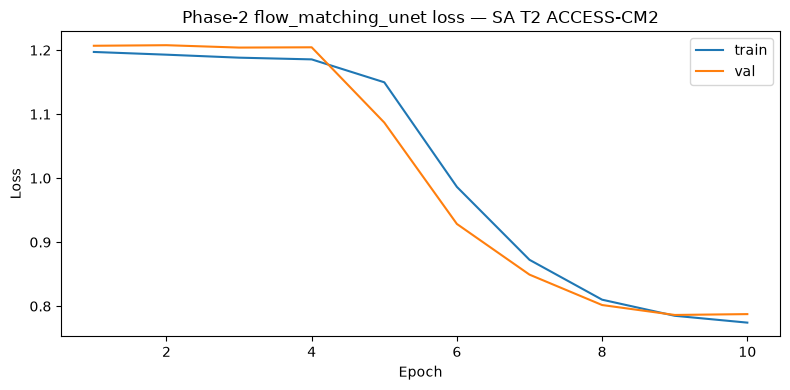

In [10]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    epochs = list(range(1, len(state.train_loss_history) + 1))
    ax.plot(epochs, state.train_loss_history, label="train")
    if state.val_loss_history:
        ax.plot(epochs, state.val_loss_history, label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Phase-2 {refinement_type} loss — SA T2 ACCESS-CM2")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available; skipping plot.")
    print("Train losses:", state.train_loss_history)
    print("Val losses  :", state.val_loss_history)

---
## Checkpoint summary

In [11]:
ckpt_dir = Path(checkpoint_dir)
print(f"Checkpoints in {ckpt_dir}:")
for f in sorted(ckpt_dir.glob("*.ckpt")):
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f.name:30s}  {size_mb:.1f} MB")
print()
best_path = ckpt_dir / "best.ckpt"
if best_path.exists():
    print(f"Best checkpoint : {best_path}")
    print(f"  -> Set model.refinement.checkpoint in your inference YAML to this path.")

Checkpoints in examples\CORDEX_ML\experiments\refinement_checkpoints\SA_T2_ACCESS-CM2_static\flow_matching_unet:
  best.ckpt                       27.1 MB
  epoch_001.ckpt                  27.1 MB
  epoch_002.ckpt                  27.1 MB
  epoch_003.ckpt                  27.1 MB
  epoch_004.ckpt                  27.1 MB
  epoch_005.ckpt                  27.1 MB
  epoch_006.ckpt                  27.1 MB
  epoch_007.ckpt                  27.1 MB
  epoch_008.ckpt                  27.1 MB
  epoch_009.ckpt                  27.1 MB
  epoch_010.ckpt                  27.1 MB
  last.ckpt                       27.1 MB

Best checkpoint : examples\CORDEX_ML\experiments\refinement_checkpoints\SA_T2_ACCESS-CM2_static\flow_matching_unet\best.ckpt
  -> Set model.refinement.checkpoint in your inference YAML to this path.
